In [18]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, PowerTransformer, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
import optuna
from sklearn.model_selection import cross_val_score, StratifiedKFold
from scripts import model_evaluation as model_eval
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImPipeline

In [19]:
X_train = pd.read_parquet('X_train_cleaned.parquet')
X_test = pd.read_parquet('X_test_cleaned.parquet')

y_train = pd.read_parquet('y_train.parquet').to_numpy()
y_test = pd.read_parquet('y_test.parquet').to_numpy()

In [20]:
X_train.info()
    

<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 3738 to 5639
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            5634 non-null   object 
 1   SeniorCitizen     5634 non-null   int64  
 2   Partner           5634 non-null   object 
 3   Dependents        5634 non-null   object 
 4   tenure            5634 non-null   int64  
 5   PhoneService      5634 non-null   object 
 6   MultipleLines     5634 non-null   object 
 7   InternetService   5634 non-null   object 
 8   OnlineSecurity    5634 non-null   object 
 9   OnlineBackup      5634 non-null   object 
 10  DeviceProtection  5634 non-null   object 
 11  TechSupport       5634 non-null   object 
 12  StreamingTV       5634 non-null   object 
 13  StreamingMovies   5634 non-null   object 
 14  Contract          5634 non-null   object 
 15  PaperlessBilling  5634 non-null   object 
 16  PaymentMethod     5634 non-null   object 
 1

In [21]:
class DropColumns(BaseEstimator, TransformerMixin):
    def __init__(self, cols):
        self.cols = cols

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.drop(columns=self.cols)

In [22]:
class FeatureEngineering(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.tenure_max_ = None

    def fit(self, X, y=None):
        self.tenure_max_ = X['tenure'].max()
        self.monthly_charge_mean_ = X['MonthlyCharges'].mean()
        return self

    def transform(self, X):
        X = X.copy()

        engagementscore = (
            (X['Contract'] != 'Month-to-month').astype(int) +
            (X['StreamingTV'] == 'Yes').astype(int) +
            (X['StreamingMovies'] == 'Yes').astype(int) +
            (X['OnlineBackup'] == 'Yes').astype(int) +
            (X['DeviceProtection'] == 'Yes').astype(int) +
            (X['TechSupport'] == 'Yes').astype(int) +
            (X['OnlineSecurity'] == 'Yes').astype(int)
        )

        X['MaturityScore'] = X['tenure'] * engagementscore
        
        X['is_new_customer'] = (X['tenure'] <= 5).astype(int)

        avg_monthly_spend = X['TotalCharges'] / (X['tenure'] + 1)
        X['cost_volatility'] = X['MonthlyCharges'] - avg_monthly_spend

        return X

In [23]:
cat_yes_no_cols = ['DeviceProtection', 'Dependents', 'PhoneService', 'OnlineBackup', 'TechSupport', 
                   'OnlineSecurity', 'PaperlessBilling']
cat_contract_cols = ['Contract']
cat_paymentmethod_cols = ['PaymentMethod']

cat_yes_no_val_order = [['Yes', 'No']]*len(cat_yes_no_cols)
cat_contract_val_order = [['Month-to-month', 'One year', 'Two year']]*len(cat_contract_cols)
cat_paymentmethod_val_order = [['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
 'Credit card (automatic)']]*len(cat_paymentmethod_cols)

num_scale_cols = ['tenure', 'MonthlyCharges', 'cost_volatility', 'MaturityScore']

drop_cols = ['gender', 'Partner', 'SeniorCitizen', 'MultipleLines', 'TotalCharges', 'StreamingTV', 'StreamingMovies', 'InternetService']
    

In [24]:
yesno_encoder_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
        ('onehot_yesno_encode', OneHotEncoder(categories=cat_yes_no_val_order, drop='first', sparse_output=False, handle_unknown='ignore')),
])

paymentmethod_encoder_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
        ('onehot_paymentmethod_encode', OneHotEncoder(categories=cat_paymentmethod_val_order, drop='first', sparse_output=False, handle_unknown='ignore')),
])

contract_encoder_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
        ('ordinal_contract_encode', OrdinalEncoder(categories=cat_contract_val_order))
])

scalling_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=-1, add_indicator=True)),
    ('scalling', StandardScaler())
])

In [25]:
preprocessor = ColumnTransformer([
    ('ohe_yesno_encoder', yesno_encoder_pipeline, cat_yes_no_cols),
    ('ohe_paymentmethod_encoder', paymentmethod_encoder_pipeline, cat_paymentmethod_cols),
    ('ordinal_contract_encoder', contract_encoder_pipeline, cat_contract_cols),
    ('scalling', scalling_pipeline, num_scale_cols),
], remainder='passthrough')

In [26]:
smote = SMOTE(
    sampling_strategy=0.5, 
    random_state=42
)

In [27]:
model_pipeline = ImPipeline([
    ('feature_engineering', FeatureEngineering()),
    ('drop_cols', DropColumns(cols=drop_cols)),
    ('preprocessing', preprocessor),
    ('smote', smote),
    ('model', LogisticRegression())
])

In [28]:
def get_params():
    return {
        "model__C":       [.005, 0.1, .01, 1, 5, 10],
        "model__penalty": ["l2"],
        "model__solver":  ["liblinear", "lbfgs"],
        "model__max_iter":  [100, 300],
    }

In [37]:
def objective(trial):

    penalty = trial.suggest_categorical(
        "penalty",
        ["l1", "l2", "elasticnet"]
    )

    solver = trial.suggest_categorical(
        "solver",
        ["liblinear", "lbfgs", "saga"]
    )

    params = {
        "model__C":        trial.suggest_float("C", 1e-4, 100.0, log=True),
        "model__penalty":  penalty,
        "model__solver":   solver,
        "model__max_iter": trial.suggest_int("max_iter", 100, 2000),
        "model__class_weight": trial.suggest_categorical("class_weight", ["balanced", None]),
    }

    if penalty == "l1" and solver == "lbfgs":
        raise optuna.TrialPruned()

    if penalty == "elasticnet" and solver != "saga":
        raise optuna.TrialPruned()

    pipeline = model_pipeline.set_params(**params)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)

    return scores.mean()

In [38]:
sampler = optuna.samplers.TPESampler(
    seed=42,
    n_startup_trials=15,        
    multivariate=True,        
    constant_liar=True      
)

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10, n_startup_trials=10)
)

study.optimize(objective, n_trials=80, timeout=3600, show_progress_bar=True)

C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``constant_liar`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-05-06 21:44:17,679] A new study created in memory with name: no-name-1af091ff-2968-439b-9c02-2b0c8e014812
Best trial: 1. Best value: 0.716275:   2%|▎         | 2/80 [00:00<00:07,  9.81it/s, 0.18/3600 seconds]

[I 2026-05-06 21:44:17,780] Trial 0 finished with value: 0.671244970364946 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.00022310108018679258, 'max_iter': 1746, 'class_weight': None}. Best is trial 0 with value: 0.671244970364946.
[I 2026-05-06 21:44:17,864] Trial 1 finished with value: 0.7162749636389643 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.006690421166498805, 'max_iter': 1097, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.7162749636389643.


Best trial: 4. Best value: 0.716925:   8%|▊         | 6/80 [00:00<00:05, 13.65it/s, 0.47/3600 seconds]

[I 2026-05-06 21:44:17,970] Trial 2 finished with value: 0.6702668059510509 and parameters: {'penalty': 'l1', 'solver': 'saga', 'C': 0.0015777663630582469, 'max_iter': 1077, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.7162749636389643.
[I 2026-05-06 21:44:17,975] Trial 3 pruned. 
[I 2026-05-06 21:44:18,061] Trial 4 finished with value: 0.7169245211317805 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.007417652034871836, 'max_iter': 1088, 'class_weight': 'balanced'}. Best is trial 4 with value: 0.7169245211317805.
[I 2026-05-06 21:44:18,146] Trial 5 finished with value: 0.42351374958585586 and parameters: {'penalty': 'l1', 'solver': 'saga', 'C': 0.0003395900933162753, 'max_iter': 472, 'class_weight': None}. Best is trial 4 with value: 0.7169245211317805.


Best trial: 7. Best value: 0.728101:  10%|█         | 8/80 [00:00<00:06, 11.96it/s, 0.67/3600 seconds]

[I 2026-05-06 21:44:18,242] Trial 6 finished with value: 0.6592028901865485 and parameters: {'penalty': 'elasticnet', 'solver': 'saga', 'C': 0.0007007213496896411, 'max_iter': 1624, 'class_weight': None}. Best is trial 4 with value: 0.7169245211317805.
[I 2026-05-06 21:44:18,348] Trial 7 finished with value: 0.7281011400405396 and parameters: {'penalty': 'l1', 'solver': 'liblinear', 'C': 4.242502238267323, 'max_iter': 240, 'class_weight': 'balanced'}. Best is trial 7 with value: 0.7281011400405396.


Best trial: 8. Best value: 0.728263:  14%|█▍        | 11/80 [00:00<00:05, 13.23it/s, 0.92/3600 seconds]

[I 2026-05-06 21:44:18,460] Trial 8 finished with value: 0.7282629693712088 and parameters: {'penalty': 'l1', 'solver': 'saga', 'C': 2.3858166771428864, 'max_iter': 1311, 'class_weight': 'balanced'}. Best is trial 8 with value: 0.7282629693712088.
[I 2026-05-06 21:44:18,465] Trial 9 pruned. 
[I 2026-05-06 21:44:18,601] Trial 10 finished with value: 0.7281910108279328 and parameters: {'penalty': 'l1', 'solver': 'saga', 'C': 65.64817611753449, 'max_iter': 1478, 'class_weight': 'balanced'}. Best is trial 8 with value: 0.7282629693712088.


Best trial: 8. Best value: 0.728263:  16%|█▋        | 13/80 [00:01<00:05, 11.21it/s, 1.13/3600 seconds]

[I 2026-05-06 21:44:18,698] Trial 11 finished with value: 0.7281910108279328 and parameters: {'penalty': 'l1', 'solver': 'saga', 'C': 75.65901102495438, 'max_iter': 1515, 'class_weight': 'balanced'}. Best is trial 8 with value: 0.7282629693712088.
[I 2026-05-06 21:44:18,808] Trial 12 finished with value: 0.7281910108279328 and parameters: {'penalty': 'l1', 'solver': 'saga', 'C': 68.60886690272446, 'max_iter': 1961, 'class_weight': 'balanced'}. Best is trial 8 with value: 0.7282629693712088.


Best trial: 8. Best value: 0.728263:  19%|█▉        | 15/80 [00:01<00:06, 10.27it/s, 1.37/3600 seconds]

[I 2026-05-06 21:44:18,932] Trial 13 finished with value: 0.7281011400405396 and parameters: {'penalty': 'l1', 'solver': 'saga', 'C': 4.0341866344830075, 'max_iter': 1362, 'class_weight': 'balanced'}. Best is trial 8 with value: 0.7282629693712088.
[I 2026-05-06 21:44:19,044] Trial 14 finished with value: 0.7281011400405396 and parameters: {'penalty': 'l1', 'solver': 'saga', 'C': 4.000979136536821, 'max_iter': 771, 'class_weight': 'balanced'}. Best is trial 8 with value: 0.7282629693712088.


Best trial: 15. Best value: 0.728501:  22%|██▎       | 18/80 [00:01<00:05, 11.68it/s, 1.57/3600 seconds]

[I 2026-05-06 21:44:19,143] Trial 15 finished with value: 0.7285012649533542 and parameters: {'penalty': 'elasticnet', 'solver': 'saga', 'C': 0.7392089492536359, 'max_iter': 1340, 'class_weight': 'balanced'}. Best is trial 15 with value: 0.7285012649533542.
[I 2026-05-06 21:44:19,143] Trial 16 pruned. 
[I 2026-05-06 21:44:19,250] Trial 17 finished with value: 0.7282717150664826 and parameters: {'penalty': 'elasticnet', 'solver': 'saga', 'C': 0.5204355218453101, 'max_iter': 1836, 'class_weight': 'balanced'}. Best is trial 15 with value: 0.7285012649533542.


Best trial: 18. Best value: 0.744058:  26%|██▋       | 21/80 [00:01<00:04, 13.11it/s, 1.78/3600 seconds]

[I 2026-05-06 21:44:19,348] Trial 18 finished with value: 0.7440584661402839 and parameters: {'penalty': 'elasticnet', 'solver': 'saga', 'C': 0.5957937721999027, 'max_iter': 1987, 'class_weight': None}. Best is trial 18 with value: 0.7440584661402839.
[I 2026-05-06 21:44:19,357] Trial 19 pruned. 
[I 2026-05-06 21:44:19,458] Trial 20 finished with value: 0.7436035841884122 and parameters: {'penalty': 'elasticnet', 'solver': 'saga', 'C': 1.055044689000712, 'max_iter': 1957, 'class_weight': None}. Best is trial 18 with value: 0.7440584661402839.


Best trial: 18. Best value: 0.744058:  29%|██▉       | 23/80 [00:01<00:04, 11.85it/s, 1.99/3600 seconds]

[I 2026-05-06 21:44:19,567] Trial 21 finished with value: 0.7436035841884122 and parameters: {'penalty': 'elasticnet', 'solver': 'saga', 'C': 0.8927477912602491, 'max_iter': 1851, 'class_weight': None}. Best is trial 18 with value: 0.7440584661402839.
[I 2026-05-06 21:44:19,665] Trial 22 finished with value: 0.7435005919215072 and parameters: {'penalty': 'elasticnet', 'solver': 'saga', 'C': 19.151889717214274, 'max_iter': 1984, 'class_weight': None}. Best is trial 18 with value: 0.7440584661402839.


Best trial: 23. Best value: 0.746432:  31%|███▏      | 25/80 [00:02<00:05, 10.98it/s, 2.20/3600 seconds]

[I 2026-05-06 21:44:19,777] Trial 23 finished with value: 0.7464323228965367 and parameters: {'penalty': 'elasticnet', 'solver': 'saga', 'C': 0.05735287837794208, 'max_iter': 1763, 'class_weight': None}. Best is trial 23 with value: 0.7464323228965367.
[I 2026-05-06 21:44:19,878] Trial 24 finished with value: 0.7444752635778391 and parameters: {'penalty': 'elasticnet', 'solver': 'saga', 'C': 0.034755830799222315, 'max_iter': 1730, 'class_weight': None}. Best is trial 23 with value: 0.7464323228965367.


Best trial: 23. Best value: 0.746432:  34%|███▍      | 27/80 [00:02<00:04, 10.72it/s, 2.40/3600 seconds]

[I 2026-05-06 21:44:19,976] Trial 25 finished with value: 0.7445797262010989 and parameters: {'penalty': 'elasticnet', 'solver': 'saga', 'C': 0.04084773961579876, 'max_iter': 1674, 'class_weight': None}. Best is trial 23 with value: 0.7464323228965367.
[I 2026-05-06 21:44:20,075] Trial 26 finished with value: 0.7437755792344201 and parameters: {'penalty': 'elasticnet', 'solver': 'saga', 'C': 0.03751175714741074, 'max_iter': 1652, 'class_weight': None}. Best is trial 23 with value: 0.7464323228965367.


Best trial: 23. Best value: 0.746432:  38%|███▊      | 30/80 [00:02<00:04, 10.51it/s, 2.59/3600 seconds]

[I 2026-05-06 21:44:20,174] Trial 27 finished with value: 0.7437755792344201 and parameters: {'penalty': 'elasticnet', 'solver': 'saga', 'C': 0.03683237014258659, 'max_iter': 1638, 'class_weight': None}. Best is trial 23 with value: 0.7464323228965367.
[I 2026-05-06 21:44:20,182] Trial 28 pruned. 
[I 2026-05-06 21:44:20,271] Trial 29 finished with value: 0.7418983914683077 and parameters: {'penalty': 'l2', 'solver': 'lbfgs', 'C': 0.01496109558002949, 'max_iter': 1462, 'class_weight': None}. Best is trial 23 with value: 0.7464323228965367.


Best trial: 30. Best value: 0.747402:  40%|████      | 32/80 [00:02<00:03, 12.01it/s, 2.79/3600 seconds]

[I 2026-05-06 21:44:20,370] Trial 30 finished with value: 0.7474022098362433 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.20729088528087197, 'max_iter': 1750, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.
[I 2026-05-06 21:44:20,470] Trial 31 finished with value: 0.7465180688711239 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.23822371984834814, 'max_iter': 1717, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.


Best trial: 30. Best value: 0.747402:  42%|████▎     | 34/80 [00:03<00:04, 11.19it/s, 3.04/3600 seconds]

[I 2026-05-06 21:44:20,581] Trial 32 finished with value: 0.7465261830511842 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.22365333807515592, 'max_iter': 1577, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.
[I 2026-05-06 21:44:20,714] Trial 33 finished with value: 0.7460459075588419 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.1648691760725993, 'max_iter': 1537, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.


Best trial: 30. Best value: 0.747402:  45%|████▌     | 36/80 [00:03<00:04, 10.34it/s, 3.23/3600 seconds]

[I 2026-05-06 21:44:20,813] Trial 34 finished with value: 0.7464577953215963 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.24841803532619539, 'max_iter': 1235, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.
[I 2026-05-06 21:44:20,904] Trial 35 finished with value: 0.7464577953215963 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.24902804724871752, 'max_iter': 1192, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.


Best trial: 30. Best value: 0.747402:  48%|████▊     | 38/80 [00:03<00:04, 10.29it/s, 3.43/3600 seconds]

[I 2026-05-06 21:44:21,002] Trial 36 finished with value: 0.7433119506461198 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 1.8195103106203123, 'max_iter': 1175, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.
[I 2026-05-06 21:44:21,107] Trial 37 finished with value: 0.7370088466507676 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.012794223950109603, 'max_iter': 917, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.


Best trial: 30. Best value: 0.747402:  50%|█████     | 40/80 [00:03<00:03, 10.15it/s, 3.63/3600 seconds]

[I 2026-05-06 21:44:21,210] Trial 38 finished with value: 0.7435005919215072 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 10.10644003310325, 'max_iter': 1585, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.
[I 2026-05-06 21:44:21,310] Trial 39 finished with value: 0.7192779076490602 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.0018527104188597694, 'max_iter': 1215, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.


Best trial: 30. Best value: 0.747402:  52%|█████▎    | 42/80 [00:03<00:03, 10.07it/s, 3.83/3600 seconds]

[I 2026-05-06 21:44:21,408] Trial 40 finished with value: 0.7461896663120461 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.2661893847725248, 'max_iter': 1394, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.
[I 2026-05-06 21:44:21,511] Trial 41 finished with value: 0.7465180688711239 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.23795538833653365, 'max_iter': 974, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.


Best trial: 30. Best value: 0.747402:  55%|█████▌    | 44/80 [00:04<00:03, 10.08it/s, 4.03/3600 seconds]

[I 2026-05-06 21:44:21,611] Trial 42 finished with value: 0.7468829126402067 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.0959303792286102, 'max_iter': 926, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.
[I 2026-05-06 21:44:21,711] Trial 43 finished with value: 0.7466114970305121 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.08718070146828612, 'max_iter': 552, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.


Best trial: 30. Best value: 0.747402:  57%|█████▊    | 46/80 [00:04<00:03,  9.81it/s, 4.25/3600 seconds]

[I 2026-05-06 21:44:21,825] Trial 44 finished with value: 0.7256675428729384 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.0033047017242725184, 'max_iter': 456, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.
[I 2026-05-06 21:44:21,923] Trial 45 finished with value: 0.7449045679723627 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.06586208435581271, 'max_iter': 119, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.


Best trial: 30. Best value: 0.747402:  60%|██████    | 48/80 [00:04<00:03, 10.09it/s, 4.44/3600 seconds]

[I 2026-05-06 21:44:22,015] Trial 46 finished with value: 0.7371305714533305 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.014628513172662077, 'max_iter': 612, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.
[I 2026-05-06 21:44:22,115] Trial 47 finished with value: 0.7469955758246737 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.09886683916198366, 'max_iter': 373, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.


Best trial: 30. Best value: 0.747402:  62%|██████▎   | 50/80 [00:04<00:02, 10.22it/s, 4.62/3600 seconds]

[I 2026-05-06 21:44:22,202] Trial 48 finished with value: 0.7464324306890447 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.08557225807563117, 'max_iter': 406, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.
[I 2026-05-06 21:44:22,302] Trial 49 finished with value: 0.6659360370771045 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.0001905536270447311, 'max_iter': 608, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.


Best trial: 30. Best value: 0.747402:  65%|██████▌   | 52/80 [00:04<00:02, 10.28it/s, 4.82/3600 seconds]

[I 2026-05-06 21:44:22,393] Trial 50 finished with value: 0.7385066258353492 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.01939667504734535, 'max_iter': 280, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.
[I 2026-05-06 21:44:22,496] Trial 51 finished with value: 0.7462197496666076 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.1409029850775882, 'max_iter': 609, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.


Best trial: 30. Best value: 0.747402:  68%|██████▊   | 54/80 [00:05<00:02, 10.37it/s, 5.01/3600 seconds]

[I 2026-05-06 21:44:22,585] Trial 52 finished with value: 0.745564730085446 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.35517498452734053, 'max_iter': 375, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.
[I 2026-05-06 21:44:22,685] Trial 53 finished with value: 0.7436602599770461 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 1.3677168850934551, 'max_iter': 702, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.


Best trial: 30. Best value: 0.747402:  70%|███████   | 56/80 [00:05<00:02, 10.24it/s, 5.21/3600 seconds]

[I 2026-05-06 21:44:22,786] Trial 54 finished with value: 0.7452604441014449 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.5828374298910017, 'max_iter': 1031, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.
[I 2026-05-06 21:44:22,887] Trial 55 finished with value: 0.7468261366331773 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.12692755325859123, 'max_iter': 1892, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.


Best trial: 30. Best value: 0.747402:  72%|███████▎  | 58/80 [00:05<00:02, 10.27it/s, 5.41/3600 seconds]

[I 2026-05-06 21:44:22,978] Trial 56 finished with value: 0.745833039223332 and parameters: {'penalty': 'l2', 'solver': 'lbfgs', 'C': 0.12527050199557993, 'max_iter': 837, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.
[I 2026-05-06 21:44:23,090] Trial 57 finished with value: 0.7237814364118169 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.021971297939692658, 'max_iter': 184, 'class_weight': 'balanced'}. Best is trial 30 with value: 0.7474022098362433.


Best trial: 30. Best value: 0.747402:  75%|███████▌  | 60/80 [00:05<00:02,  9.63it/s, 5.64/3600 seconds]

[I 2026-05-06 21:44:23,191] Trial 58 finished with value: 0.7337907868298579 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.007887647194299022, 'max_iter': 1897, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.
[I 2026-05-06 21:44:23,314] Trial 59 finished with value: 0.7437688530506847 and parameters: {'penalty': 'l1', 'solver': 'liblinear', 'C': 0.4528794222368888, 'max_iter': 358, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.


Best trial: 30. Best value: 0.747402:  78%|███████▊  | 62/80 [00:05<00:01,  9.77it/s, 5.83/3600 seconds]

[I 2026-05-06 21:44:23,405] Trial 60 finished with value: 0.7444568369053307 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.06453999718778074, 'max_iter': 533, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.
[I 2026-05-06 21:44:23,510] Trial 61 finished with value: 0.7465083780198029 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.169123465645539, 'max_iter': 1838, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.


Best trial: 30. Best value: 0.747402:  80%|████████  | 64/80 [00:06<00:01, 10.02it/s, 6.02/3600 seconds]

[I 2026-05-06 21:44:23,601] Trial 62 finished with value: 0.7468829126402067 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.09298881011811723, 'max_iter': 1923, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.
[I 2026-05-06 21:44:23,700] Trial 63 finished with value: 0.7464324306890447 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.08482713297690961, 'max_iter': 1907, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.


Best trial: 30. Best value: 0.747402:  82%|████████▎ | 66/80 [00:06<00:01, 10.11it/s, 6.22/3600 seconds]

[I 2026-05-06 21:44:23,792] Trial 64 finished with value: 0.7439907152705343 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.05611756050544966, 'max_iter': 1821, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.
[I 2026-05-06 21:44:23,894] Trial 65 finished with value: 0.7305329049325526 and parameters: {'penalty': 'l2', 'solver': 'lbfgs', 'C': 0.024639262311462656, 'max_iter': 1909, 'class_weight': 'balanced'}. Best is trial 30 with value: 0.7474022098362433.


Best trial: 30. Best value: 0.747402:  85%|████████▌ | 68/80 [00:06<00:01, 10.07it/s, 6.42/3600 seconds]

[I 2026-05-06 21:44:23,994] Trial 66 finished with value: 0.7453723456004515 and parameters: {'penalty': 'l1', 'solver': 'liblinear', 'C': 0.11098947358177516, 'max_iter': 1998, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.
[I 2026-05-06 21:44:24,096] Trial 67 finished with value: 0.7440888478865348 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.7629985847475583, 'max_iter': 1758, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.


Best trial: 30. Best value: 0.747402:  88%|████████▊ | 70/80 [00:06<00:00, 10.06it/s, 6.62/3600 seconds]

[I 2026-05-06 21:44:24,193] Trial 68 finished with value: 0.74515781480364 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.41181707761782366, 'max_iter': 1125, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.
[I 2026-05-06 21:44:24,294] Trial 69 finished with value: 0.7461338777412226 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.15737099767840343, 'max_iter': 1541, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.


Best trial: 30. Best value: 0.747402:  90%|█████████ | 72/80 [00:06<00:00, 10.12it/s, 6.81/3600 seconds]

[I 2026-05-06 21:44:24,386] Trial 70 finished with value: 0.7281904517624447 and parameters: {'penalty': 'l2', 'solver': 'lbfgs', 'C': 2.4359772775019652, 'max_iter': 1680, 'class_weight': 'balanced'}. Best is trial 30 with value: 0.7474022098362433.
[I 2026-05-06 21:44:24,488] Trial 71 finished with value: 0.7463954332018066 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.1881693253727565, 'max_iter': 1720, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.


Best trial: 30. Best value: 0.747402:  92%|█████████▎| 74/80 [00:07<00:00, 10.02it/s, 7.02/3600 seconds]

[I 2026-05-06 21:44:24,595] Trial 72 finished with value: 0.7467875366069917 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.08708124798312808, 'max_iter': 1812, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.
[I 2026-05-06 21:44:24,690] Trial 73 finished with value: 0.7466114970305121 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.08755250849554057, 'max_iter': 1811, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.


Best trial: 30. Best value: 0.747402:  95%|█████████▌| 76/80 [00:07<00:00, 10.01it/s, 7.21/3600 seconds]

[I 2026-05-06 21:44:24,784] Trial 74 finished with value: 0.7442594703370726 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.05013388682205764, 'max_iter': 1918, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.
[I 2026-05-06 21:44:24,890] Trial 75 finished with value: 0.746256650589676 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.08417002008909304, 'max_iter': 1791, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.


Best trial: 30. Best value: 0.747402:  98%|█████████▊| 78/80 [00:07<00:00, 10.18it/s, 7.40/3600 seconds]

[I 2026-05-06 21:44:24,985] Trial 76 finished with value: 0.7425067198758499 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.02674683270232577, 'max_iter': 1853, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.
[I 2026-05-06 21:44:25,081] Trial 77 finished with value: 0.42351374958585586 and parameters: {'penalty': 'l1', 'solver': 'liblinear', 'C': 0.00044258716530602314, 'max_iter': 1869, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.


Best trial: 30. Best value: 0.747402: 100%|██████████| 80/80 [00:07<00:00, 10.53it/s, 7.60/3600 seconds]

[I 2026-05-06 21:44:25,173] Trial 78 finished with value: 0.7342571205920457 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.008151493772268823, 'max_iter': 1801, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.
[I 2026-05-06 21:44:25,273] Trial 79 finished with value: 0.743476188390469 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.04193702904688959, 'max_iter': 1949, 'class_weight': None}. Best is trial 30 with value: 0.7474022098362433.


In [39]:
print("Best F1 Macro:", study.best_value)
print("Best params:", study.best_params)

Best F1 Macro: 0.7474022098362433
Best params: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.20729088528087197, 'max_iter': 1750, 'class_weight': None}


In [40]:
best_params = {f"model__{k}": v for k, v in study.best_params.items()}

best_params

{'model__penalty': 'l2',
 'model__solver': 'liblinear',
 'model__C': 0.20729088528087197,
 'model__max_iter': 1750,
 'model__class_weight': None}

In [41]:
best_pipeline = model_pipeline.set_params(**best_params)
best_pipeline.fit(X_train, y_train)

C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,steps,"[('feature_engineering', ...), ('drop_cols', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,cols,"['gender', 'Partner', ...]"
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ohe_yesno_encoder', ...), ('ohe_paymentmethod_encoder', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False


In [42]:
optuna.visualization.plot_param_importances(study)

In [43]:
optuna.visualization.plot_optimization_history(study)

In [45]:
best_model = best_pipeline.named_steps['model']
feature_names = best_pipeline.named_steps['preprocessing'].get_feature_names_out()
feature_names

array(['ohe_yesno_encoder__DeviceProtection_No',
       'ohe_yesno_encoder__Dependents_No',
       'ohe_yesno_encoder__PhoneService_No',
       'ohe_yesno_encoder__OnlineBackup_No',
       'ohe_yesno_encoder__TechSupport_No',
       'ohe_yesno_encoder__OnlineSecurity_No',
       'ohe_yesno_encoder__PaperlessBilling_No',
       'ohe_paymentmethod_encoder__PaymentMethod_Mailed check',
       'ohe_paymentmethod_encoder__PaymentMethod_Bank transfer (automatic)',
       'ohe_paymentmethod_encoder__PaymentMethod_Credit card (automatic)',
       'ordinal_contract_encoder__Contract', 'scalling__tenure',
       'scalling__MonthlyCharges', 'scalling__cost_volatility',
       'scalling__MaturityScore', 'remainder__is_new_customer'],
      dtype=object)

In [48]:
y_proba = best_pipeline.predict_proba(X_test)[:, 1]
y_pred = best_pipeline.predict(X_test)

In [50]:
coefs = best_pipeline.named_steps['model'].coef_[0]

In [51]:
coef_df = (
    pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefs,
    })
    .assign(abs_coefficient=lambda df: df["coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False)
    .reset_index(drop=True)
)

In [52]:
coef_df

,feature,coefficient,abs_coefficient
0,ordinal_contract_encoder__Contract,-0.969849,0.969849
1,ohe_yesno_encoder__PhoneService_No,0.903984,0.903984
2,scalling__MonthlyCharges,0.899357,0.899357
3,scalling__tenure,-0.567579,0.567579
4,ohe_yesno_encoder__OnlineSecurity_No,0.567482,0.567482
5,ohe_yesno_encoder__TechSupport_No,0.515210,0.515210
6,ohe_paymentmethod_encoder__PaymentMethod_Credi...,-0.469771,0.469771
7,ohe_paymentmethod_encoder__PaymentMethod_Bank ...,-0.430866,0.430866
8,ohe_yesno_encoder__OnlineBackup_No,0.421254,0.421254
9,ohe_paymentmethod_encoder__PaymentMethod_Maile...,-0.409192,0.409192


EVALUATION REPORT
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      1035
           1       0.61      0.63      0.62       374

    accuracy                           0.79      1409
   macro avg       0.74      0.74      0.74      1409
weighted avg       0.80      0.79      0.80      1409

Macro F1 Score:    0.7396


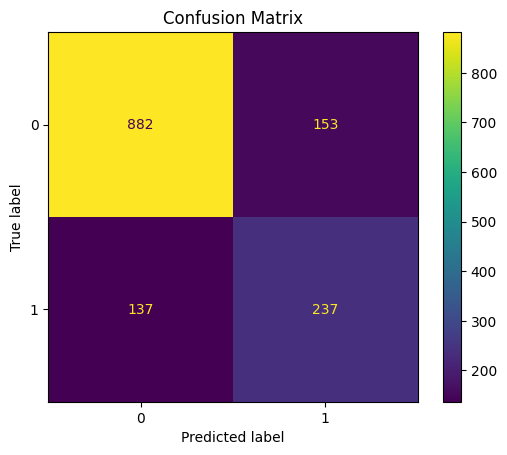

PR AUC Score: 0.661


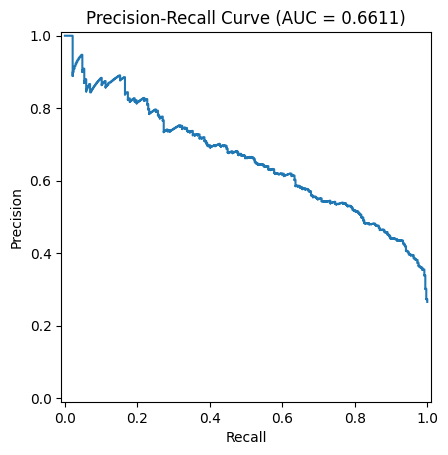

In [53]:
model_eval.evaluate_model(y_test, y_pred, y_proba)